In [96]:
%load_ext autoreload
%autoreload 2

import os
import sys
    
sys.path.insert(1, os.path.dirname(os.path.dirname(os.getcwd())))
import precision_mapping as pm

# Loads test suite paths
from precision_mapping.tests.constants_test_suite import *

In [2]:
dtseries_path = TEST_DTSERIES_PATH  # path to dtseries or .txt with lines of dtseries paths
subject_id = TEST_SUBJECT_ID  # name of subject (output directory will use this)
sample_label = TEST_SAMPLE_LABEL # sample label (normally '{subject}_additional_info')
outdir = TEST_DIR_PATH # output directory
censor_file = TEST_DTSERIES_CENSOR_FILE # path to frame censoring .dat file

# pm.precision_mapping(dtseries_path, subject_id, sample_label, outdir,
#                      censor_files=censor_file, device="default", seed=4,
#                      sparsity=0.01, n_infomaps_reps=1, overwrite=True)

In [3]:

dtseries_path = '/System/Volumes/Data/data/data7/HCP_7T/100610/MNINonLinear/Results/rfMRI_REST_7T_ALL/rfMRI_REST_7T_ALL_Atlas_hp2000_clean_nilearn.dtseries.nii'
censor_file = None
npz_path = "/data/data7/network_control/projects/pfm_analysis/results/HCP_analysis/100610/100610_rfMRI_REST_7T_ALL_vertex_FC.npz"

# Rewriting core sparse_correlator :(

In [4]:
import scipy
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [86]:
mask = scipy.sparse.load_npz(pm.constants.DEFAULT_MASK)

sparsity = 0.1
voxel_data = pm.cifti_tools.load_voxel_data(dtseries_path, censor_file=censor_file)
exclude_index = np.arange(voxel_data.shape[1]) >= 59_412

block_size=1000
leave=False
SC_kwargs = {}

backend = np
backend = torch

In [87]:
zmat = pm.sparse_correlator.top_row_correlations(voxel_data, sparsity=0.01, window_size=100, mask=mask,
                                                 backend="torch", device="mps", exclude_index=exclude_index, leave=False)
# scipy.sparse.save_npz(npz_path, zmat)

Top K Sparse Correlation:   0%|          | 0/913 [00:00<?, ?it/s]

In [30]:
scipy.sparse.save_npz(npz_path, zmat)

In [498]:
12574273 / 91282

137.75194452356433

In [474]:
scipy.sparse.save_npz(npz_path, zmat)

In [482]:
hmat = scipy.sparse.load_npz(npz_path)

In [480]:
zmat

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 83340466 stored elements and shape (91282, 91282)>

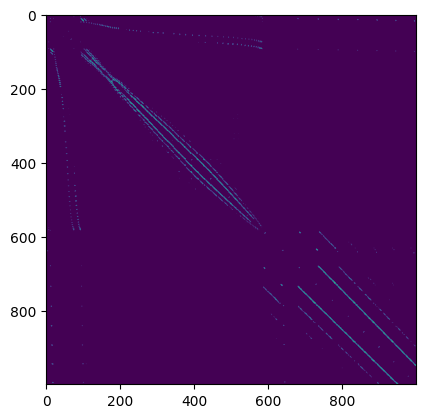

In [28]:
plt.imshow(zmat[:1000, :1000].todense())

In [270]:
x = pm.spc_utils.to_backend(backend, voxel_data)
y = pm.spc_utils.to_backend(backend, voxel_data)

x, y = x.T, y.T
x_demeaned = x - x.mean(axis=1, keepdims=True)
y_demeaned = y - y.mean(axis=1, keepdims=True)

x_norm = x_demeaned / backend.sqrt(backend.sum(x_demeaned ** 2, axis=1, keepdims=True))
y_norm = y_demeaned / backend.sqrt(backend.sum(y_demeaned ** 2, axis=1, keepdims=True))

n_vertices = y_norm.shape[0]
k_top_vertices = int(np.ceil(sparsity * y_norm.shape[0]))
k_top_vertices

913

In [429]:
window_size = 100

n_windows = int(np.ceil(y_norm.shape[0] / window_size))
c_x_indices, c_values = [], []
for i in tqdm(range(n_windows)):
    window_start_index = i * window_size
    window_end_index = window_start_index + window_size
    y_window_slice = slice(window_start_index, window_start_index + window_size)
    y_window = y_norm[y_window_slice]

    corr_window = (x_norm @ y_window.T)
    # excludes diagonal
    corr_window[np.arange(window_start_index, window_end_index), np.arange(window_size)] = 0
    # excludes exclude_index
    corr_window[exclude_index] = 0

    # excludes mask
    mask_window = ~pm.spc_utils.sparse_to_array(mask[:, y_window_slice].astype(bool))
    mask_window = pm.spc_utils.to_backend(backend, mask_window, dtype=bool, **device_info)
    corr_window = corr_window * mask_window
    
    cw_values, cw_x_indices = pm.spc_utils.MPS_safe_topk(backend, device_info, corr_window, k_top_vertices, axis=0)
    c_x_indices.append(cw_x_indices)
    c_values.append(cw_values)
    
    if i > -1:
        break

c_values = backend.concat(c_values, axis=1)
c_x_indices = backend.concat(c_x_indices, axis=1)
c_y_indices = backend.arange(n_vertices).tile(k_top_vertices, 1)

  0%|          | 0/913 [00:00<?, ?it/s]

In [430]:
mask_window = ~pm.spc_utils.sparse_to_array(mask[:, y_window_slice].astype(bool))
mask_window = pm.spc_utils.to_backend(backend, mask_window, dtype=bool, **device_info)

In [431]:
mask_window.shape

torch.Size([91282, 100])

In [432]:
corr_window[np.arange(window_start_index, window_end_index), np.arange(window_size)] = 0

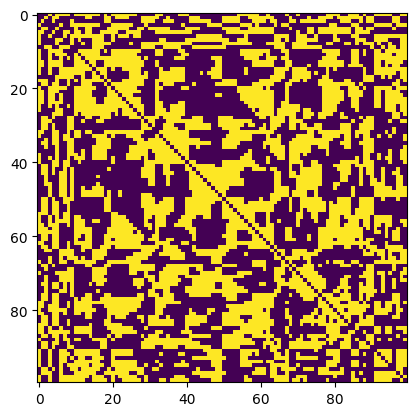

In [433]:
plt.imshow(corr_window[y_window_slice, :window_size] > 0)

In [365]:
z = corr_window * mask_window

In [366]:
torch.sum(z[:, 0] > 0)

tensor(45908)

In [275]:
corr_window[exclude_index] = 0

In [276]:
corr_window

tensor([[ 1.4445e-01,  5.1904e-01,  6.8831e-01,  ..., -3.6970e-01,
          1.1788e-01,  2.3520e-01],
        [-6.9083e-01,  4.6165e-01,  2.7206e-01,  ..., -1.2637e-01,
         -3.9806e-01,  5.3681e-01],
        [-4.8422e-01, -2.0935e-01, -5.3943e-01,  ...,  3.8183e-01,
         -4.8683e-01,  3.2666e-05],
        ...,
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])

In [220]:
c_x_indices = c_x_indices.ravel()
c_y_indices = c_y_indices.ravel()
c_values = c_values.ravel()

In [221]:
tv, ri, ci = pm.spc_utils.to_np((c_values, c_x_indices, c_y_indices))

In [222]:
zmat = scipy.sparse.csr_matrix((tv, (ri.astype(int), ci.astype(int))), shape=(n_vertices, n_vertices))

In [224]:
scipy.sparse.save_npz(npz_path, sc)

In [208]:
pm.spc_utils.get_nnz_safe(zmat)

83340466

In [85]:
x_norm.shape, y_norm.shape, yns.shape

(torch.Size([91282, 29]), torch.Size([91282, 29]), torch.Size([3, 29]))

In [101]:
z = (x_norm @ yns.T)
print(z.shape)

torch.Size([91282, 3])


In [102]:
device_info = pm.spc_utils.get_device_info(backend, "cpu")

In [103]:
k_top_vertices = int(np.ceil(sparsity * voxel_data.shape[1]))

In [106]:
pm.spc_utils.MPS_safe_topk(backend, device_info, z, k_top_vertices, axis=0)[0].shape

torch.Size([913, 3])

In [107]:
z[np.argsort(z[:, 0])[-k_top_vertices:], 0]

tensor([0.8260, 0.8260, 0.8260, 0.8260, 0.8260, 0.8261, 0.8261, 0.8262, 0.8262,
        0.8262, 0.8263, 0.8263, 0.8266, 0.8266, 0.8267, 0.8267, 0.8268, 0.8268,
        0.8268, 0.8269, 0.8271, 0.8273, 0.8273, 0.8273, 0.8273, 0.8274, 0.8274,
        0.8275, 0.8275, 0.8275, 0.8276, 0.8276, 0.8276, 0.8276, 0.8276, 0.8276,
        0.8277, 0.8277, 0.8277, 0.8278, 0.8279, 0.8280, 0.8280, 0.8281, 0.8282,
        0.8282, 0.8282, 0.8285, 0.8286, 0.8286, 0.8286, 0.8287, 0.8287, 0.8288,
        0.8289, 0.8289, 0.8289, 0.8290, 0.8291, 0.8291, 0.8293, 0.8293, 0.8294,
        0.8295, 0.8296, 0.8297, 0.8298, 0.8298, 0.8298, 0.8299, 0.8299, 0.8299,
        0.8300, 0.8301, 0.8301, 0.8301, 0.8301, 0.8302, 0.8302, 0.8303, 0.8303,
        0.8303, 0.8304, 0.8305, 0.8305, 0.8307, 0.8307, 0.8307, 0.8309, 0.8309,
        0.8310, 0.8312, 0.8313, 0.8313, 0.8313, 0.8313, 0.8314, 0.8314, 0.8314,
        0.8315, 0.8315, 0.8316, 0.8316, 0.8316, 0.8317, 0.8318, 0.8319, 0.8319,
        0.8320, 0.8320, 0.8320, 0.8320, 

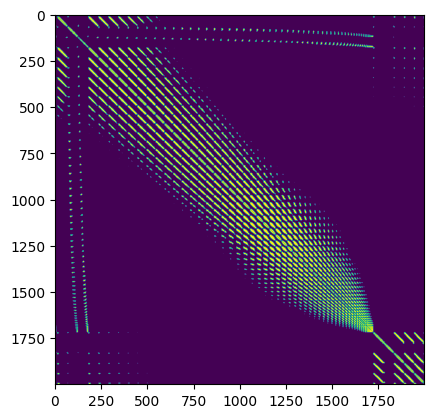

In [333]:
plt.imshow(pm.spc_utils.sparse_to_array(mask[:2000, :2000]))

In [21]:

sc = pm.sparse_correlator.SparseCorrelator.run(voxel_data, sparsity_percent=sparsity, symmetric=True,
                          mask=mask, exclude_index=exclude_index,
                          block_size=block_size, leave=leave, **SC_kwargs)

SparseCorrelator Block Analysis:   0%|          | 0/4278.0 [00:00<?, ?it/s]

In [3]:
from precision_mapping import functional_connectivity as fc

In [4]:
fc.generate_correlation_matrix(TEST_DTSERIES_PATH, TEST_OUTPUT_VERTEX_FC_PATH,
                               censor_file=TEST_DTSERIES_CENSOR_FILE,
                               sparsity=0.01,
                               exclude_index_path=None,
                               mask=30,
                                block_size=2_000,
                                overwrite=True, leave=True)

SparseCorrelator Block Analysis:   0%|          | 0/4324.0 [00:00<?, ?it/s]

'/System/Volumes/Data/data/data7/network_control/projects/precision_mapping/tests/outputs/example_vertex_FC.npz'

# Multi layer infomaps flow test

In [1]:
import sys
import os
import glob
import scipy
import itertools

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns


from tqdm.auto import tqdm
from infomap import Infomap
from sklearn.metrics import normalized_mutual_info_score as nmis

sys.path.insert(1, os.path.dirname(os.path.dirname(os.getcwd())))
import precision_mapping as pm

In [2]:
test_dir = "/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/"

network_partition_paths = glob.glob(test_dir + "*duration-25m*network_partition.npy")
pfm_parcel_partition_paths = glob.glob(test_dir + "*duration-25m*parcel_partition.npy")

pfm_vfc_paths = glob.glob(test_dir + "*duration-25m*FC.npz")
hcp_vfc_paths = glob.glob("/data/data7/network_control/projects/pfm_analysis/results/HCP_analysis/*/*_rfMRI_REST_7T_ALL_*.npz")

In [3]:
hcp_parcel_partition_paths = glob.glob("/data/data7/network_control/projects/pfm_analysis/results/HCP_analysis/*/*_rfMRI_REST_7T_ALL_*parcel_partition.npy")

In [4]:
def load_partitions(parcel_partition_paths):
    parcel_partitions = [np.load(p) for p in parcel_partition_paths]
    parcel_partitions = np.array([p[1] for p in parcel_partitions])
    return parcel_partitions[:, ~np.isnan(parcel_partitions).any(axis=0)].astype(int)
    
def calculate_overlap_score_from_npy(parcel_partition_paths, metric=nmis):
    """ """
    parcel_partitions = load_partitions(parcel_partition_paths)
    scores = [metric(p1, p2) for p1, p2 in list(itertools.combinations(parcel_partitions, 2))]
    return scores

def mean_dice_score(z, h):
    dice_s = [2 * np.sum((z == i) & (h == i)) / (np.sum(z == i) + np.sum(h == i)) for i in np.sort(np.unique(z))]
    return np.mean(dice_s)

def accuracy(z, h):
    return np.mean(z == h) * 100

def co_cluster_percent(p1, p2):
    return np.sum([np.max(np.unique(p2[p1 == i], return_counts=True)[1]) for i in np.unique(p1)]) / len(p1) * 100

In [30]:
def calculate_overlap_score_npz(vfc_paths=None, save_csv_path=None, overwrite=False, metric=nmis, mlr_rate=0.15):
    """ """

    if vfc_paths is not None and (overwrite or save_csv_path is None or (not os.path.exists(save_csv_path))):
        sparse_vFC_s = [scipy.sparse.load_npz(p) for p in vfc_paths]
    
        matrices = sparse_vFC_s    
        im = Infomap(multilayer_relax_limit=1, multilayer_relax_rate=mlr_rate, no_self_links=True, clu_level=2)
        n = np.sum([vfc.nnz for vfc in matrices])
        
        for layer, matrix in enumerate(matrices):
            matrix = matrix[:5000, :5000]
            pbar = tqdm(desc="Adding links", total=matrix.nnz, leave=True)
            for r_i, c_i, fc_i in zip(*matrix.nonzero(), matrix.data):
                im.add_multilayer_intra_link(layer, r_i, c_i, weight=fc_i)
                pbar.update(1)
            pbar.close()
    
        im.run(num_trials=1)
    
        # partition_df = []
        # for node in im.nodes:
        #     partition_df.append([node.module_id, node.layer_id, node.node_id])
        # partition_df = pd.DataFrame(partition_df, columns=["mod", "layer", "node"])

        partition_df = pd.DataFrame([[node.physicalId, node.stateId, node.layerId] for node in im.iterTree()],
                 columns=["physical_id", "state_id", "layer"])
        partition_df = partition_df.drop_duplicates()
        
        mdl1 = im.get_modules(depth_level=1, states=True)
        mdl2 = im.get_modules(depth_level=2, states=True)
        
        partition_df["mod_depth1"] = partition_df["state_id"].map(mdl1.get)
        partition_df["mod_depth2"] = partition_df["state_id"].map(mdl2.get)
    
        if save_csv_path:
            partition_df.to_csv(save_csv_path)
    else:
        partition_df = pd.read_csv(save_csv_path)

    partition_array = np.full((len(partition_df["layer"].unique()), 91_282), fill_value=np.nan)
    for layer, df in partition_df.groupby("layer"):
        partition_array[layer][df["physical_id"]] = df["mod_depth2"]
    partition_array = partition_array[:, ~np.isnan(partition_array).any(axis=0)]
    
    imf_scores = [metric(p1, p2) for p1, p2 in list(itertools.combinations(partition_array, 2))]
    return imf_scores, partition_df #, im

In [29]:
_, hcp_tdf, im = calculate_overlap_score_npz(hcp_vfc_paths, overwrite=False, mlr_rate=0.05)

Adding links:   0%|          | 0/200650 [00:00<?, ?it/s]

Adding links:   0%|          | 0/185522 [00:00<?, ?it/s]

Adding links:   0%|          | 0/209643 [00:00<?, ?it/s]

. Found 4 levels with codelength 9.06208495

=> Trial 1/1 finished in 20.0701272s with codelength 9.06208495


Summary after 1 trial
Best end modular solution in 4 levels:
Per level number of modules:         [          6,          77,           5,           0] (sum: 88)
Per level number of leaf nodes:      [          0,           0,       14448,         491] (sum: 14939)
Per level average child degree:      [          6,     12.8333,     187.701,        98.2] (average: 183.808)
Per level codelength for modules:    [0.187167868, 1.216381105, 0.045422001, 0.000000000] (sum: 1.448970973)
Per level codelength for leaf nodes: [0.000000000, 0.000000000, 7.389238046, 0.223875932] (sum: 7.613113977)
Per level codelength total:          [0.187167868, 1.216381105, 7.434660046, 0.223875932] (sum: 9.062084950)

  Infomap ends at 2026-01-23 11:51:09
  (Elapsed time: 28.2329197s)
  Infomap v2.8.0 starts at 2026-01-23 12:03:22
  -> Input network: 
  -> No file output!
  -> Configuration: no-self-lin

In [151]:
subject_ids, sample_labels = [], []
dtseries_paths, censor_files = [], []
for p in pfm_parcel_partition_paths:
    subject_ids.append(p.split("/")[6])
    sample_labels.append(p.split("/")[-1].split("_parcel")[0] + "_IMF")
    
    dtseries_path_i = os.path.dirname(p) + "/bolddata/" + os.path.basename(p).split("_parcel")[0] + ".dtseries.nii"
    assert os.path.exists(dtseries_path_i)
    censor_file_i = dtseries_path_i.replace("bolddata", "frcnsr_lists").split("_space")[0] + "_include.dat"
    assert os.path.exists(censor_file_i)
    
    dtseries_paths.append(dtseries_path_i)
    censor_files.append(censor_file_i)

out_dir = os.path.dirname(p) + "/pfm_IMF/"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [152]:
paths = pm.utils.create_pm_paths(subject_ids, sample_labels, out_dir, method="infomaps")

In [158]:
_, pfm_pdf = calculate_overlap_score_npz(save_csv_path="imf_save.csv")

pfm_imf_partitions = []
for i, parcel_partition_path in enumerate(paths["parcel-partition"]):
    layer_partition_df = pfm_pdf.loc[pfm_pdf["layer"] == i].sort_values("node")
    indices = layer_partition_df["node"].values
    groups = layer_partition_df["mod"].values
    
    pfm_imf_partitions.append((indices, groups))
    pm.parcellate.save_partition(indices, groups, parcel_partition_path)

In [164]:
pfm_pdf

,Unnamed: 0,mod,layer,node
0,0,1,1,2843
1,1,1,1,2844
2,2,1,1,2813
3,3,1,1,2812
4,4,1,1,2842
...,...,...,...,...
273020,273020,11,2,91025
273021,273021,11,2,90752
273022,273022,11,2,91006
273023,273023,11,2,90890


In [162]:
overwrite = False
pm.na.assign_networks_batch(dtseries_paths, paths["parcel-partition"], paths["network-partition"], censor_files=censor_files, overwrite=overwrite)

o_kwargs = dict(template_cifti=dtseries_paths[0], overwrite=overwrite)
pm.partition_tools.write_parcel_dlabel(paths["parcel-partition"], paths["parcel-dlabel"], **o_kwargs)
pm.partition_tools.write_network_dlabel(paths["network-partition"], paths["network-dlabel"], **o_kwargs)
pm.partition_tools.calculate_network_surface_areas(paths["network-partition"], paths["network-size-csv"], **o_kwargs)
pm.plot.QC_plots(paths["parcel-partition"], save_path=paths["qc-plot"], overwrite=overwrite)
pm.plot.parcel_plot(paths["parcel-partition"], paths["network-partition"],
                 sample_labels, paths["parcel-plot"], **o_kwargs)

Assigning parcellation networks:   0%|          | 0/3 [00:00<?, ?cifti/s]

/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508131400_task-rest_duration-25m_num-1_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_network_partition.npy already exists and no '--overwrite' flag given. Skipping network assignment.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508281400_task-rest_duration-25m_num-2_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_network_partition.npy already exists and no '--overwrite' flag given. Skipping network assignment.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2510021400_task-rest_duration-25m_num-3_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_network_partition.npy already exists and no '--overwrite' flag given. Skipping network assignment.


Writing parcel dlabel:   0%|          | 0/3 [00:00<?, ?it/s]

Writing network dlabel:   0%|          | 0/3 [00:00<?, ?it/s]

Writing network size csvs:   0%|          | 0/3 [00:00<?, ?it/s]

Generating QC plots:   0%|          | 0/3 [00:00<?, ?it/s]

Generating parcel plots:   0%|          | 0/3 [00:00<?, ?it/s]

# Overlap Score Analysis 

In [34]:
_, _ = calculate_overlap_score_npz(pfm_vfc_paths, save_csv_path="imf_save.csv", overwrite=False)

KeyError: 'mod_depth2'

In [43]:
mlr_rate_s = [0.01, 0.05, 0.10]
hcp_imf_ccp_mlr_scores = {}
pbar = tqdm(desc="Running MLR tests", total=2 * len(mlr_rate_s))

for mlr_rate in mlr_rate_s:
    mlr_rate_str = f"{mlr_rate:.02f}"[-2:]
    hcp_imf_mlr_ccp_score, _ = calculate_overlap_score_npz(hcp_vfc_paths, save_csv_path=f"imf_hcp_save_mlr_{mlr_rate_str}.csv",
                                      overwrite=False, mlr_rate=mlr_rate, metric=co_cluster_percent)
    hcp_imf_ccp_mlr_scores[mlr_rate] = hcp_imf_mlr_ccp_score
    pbar.update(1)

# for mlr_rate in mlr_rate_s:
#     mlr_rate_str = f"{mlr_rate:.02f}"[-2:]
#     calculate_overlap_score_npz(pfm_vfc_paths, save_csv_path=f"imf_pfm_save_mlr_{mlr_rate_str}.csv", overwrite=False, mlr_rate=mlr_rate)
#     pbar.update(1)

Running MLR tests:   0%|          | 0/6 [00:00<?, ?it/s]

In [33]:
# pfm_imi_nmis_scores = calculate_overlap_score_from_npy(pfm_parcel_partition_paths)
hcp_imi_nmis_scores = calculate_overlap_score_from_npy(hcp_parcel_partition_paths)

pfm_imf_nmis_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_save.csv")
hcp_imf_nmis_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_hcp_save.csv", overwrite=False)

KeyError: 'mod_depth2'

In [170]:
# pfm_imf_ccp_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_save.csv", metric=accuracy)
# hcp_imf_ccp_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_hcp_save.csv", metric=accuracy)

pfm_imf_ccp_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_save.csv", metric=co_cluster_percent)
hcp_imf_ccp_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_hcp_save.csv", metric=co_cluster_percent)

# pfm_imi_ccp_scores = calculate_overlap_score_from_npy(pfm_parcel_partition_paths, metric=co_cluster_percent)
# hcp_imi_ccp_scores = calculate_overlap_score_from_npy(hcp_parcel_partition_paths, metric=co_cluster_percent)

In [46]:
cdf = pd.DataFrame({"Individual - PFM Subject": pfm_imi_ccp_scores,
                    "Individual - Random HCP:7T Subjects": hcp_imi_ccp_scores,
                   "Multilayer Flow - PFM Subject":pfm_imf_ccp_scores,
                   "Multilayer Flow - Random HCP:7T Subjects":hcp_imf_ccp_scores,
                   "x": np.arange(3)})

cd = cdf.melt(id_vars=["x"])
cd["method"] = cd["variable"].str.split("-").str[0].str.strip()
cd["samples"] = cd["variable"].str.split("-").str[1].str.strip()

<Axes: xlabel='variable', ylabel='value'>

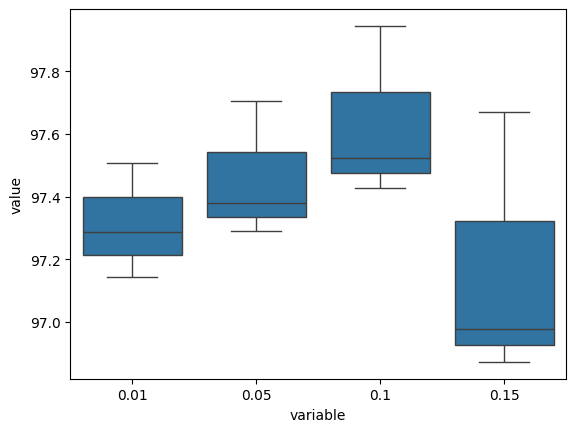

In [47]:
mdf = pd.DataFrame(hcp_imf_ccp_mlr_scores)
mdf[0.15] = hcp_imf_ccp_scores
sns.boxplot(data=mdf.melt(), x="variable", y="value")

In [268]:
sdf = pd.DataFrame({
                   "Individual - PFM Subject": pfm_imi_nmis_scores,
                   "Multilayer Flow - PFM Subject":pfm_imf_nmis_scores,
                   "Individual - Random HCP:7T Subjects": hcp_imi_nmis_scores,
                   "Multilayer Flow - Random HCP:7T Subjects":hcp_imf_nmis_scores,
                   "x": np.arange(3)})
sd = sdf.melt(id_vars=["x"])
sd["method"] = sd["variable"].str.split("-").str[0].str.strip()
sd["samples"] = sd["variable"].str.split("-").str[1].str.strip()
sd

,x,variable,value,method,samples
0,0,Individual - PFM Subject,0.787181,Individual,PFM Subject
1,1,Individual - PFM Subject,0.765647,Individual,PFM Subject
2,2,Individual - PFM Subject,0.763175,Individual,PFM Subject
3,0,Multilayer Flow - PFM Subject,0.943471,Multilayer Flow,PFM Subject
4,1,Multilayer Flow - PFM Subject,0.931611,Multilayer Flow,PFM Subject
5,2,Multilayer Flow - PFM Subject,0.930623,Multilayer Flow,PFM Subject
6,0,Individual - Random HCP:7T Subjects,0.747415,Individual,Random HCP:7T Subjects
7,1,Individual - Random HCP:7T Subjects,0.757820,Individual,Random HCP:7T Subjects
8,2,Individual - Random HCP:7T Subjects,0.765780,Individual,Random HCP:7T Subjects
9,0,Multilayer Flow - Random HCP:7T Subjects,0.931516,Multilayer Flow,Random HCP:7T Subjects


/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_27251/2869048753.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=cd, y="method", x="value", hue="samples", palette=["C0", "cyan"], ax=a1)


(-3.969776001822018, 109.0)

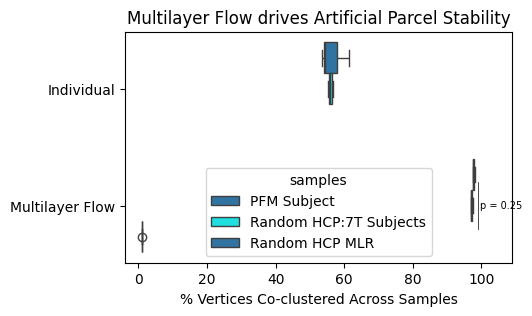

In [35]:
fig, a1 = plt.subplots(figsize=(5, 3))

sns.boxplot(data=cd, y="method", x="value", hue="samples", palette=["C0", "cyan"], ax=a1)
a1.set(ylabel="", xlabel="% Vertices Co-clustered Across Samples")
a1.set_title("Multilayer Flow drives Artificial Parcel Stability")

t, p = scipy.stats.ttest_ind(cd.query("variable == 'Multilayer Flow - Random HCP:7T Subjects'")["value"],
                      cd.query("variable == 'Multilayer Flow - PFM Subject'")["value"])

a1.plot([99.1, 99.1], [0.8, 1.2], color="k", linewidth=0.5)
a1.plot([99.05, 99.1], [1.2, 1.2], color="k", linewidth=0.5)
a1.plot([99.05, 99.1], [.8, 0.8], color="k", linewidth=0.5)
a1.text(99.5, 1, f"p = {p:.2f}", va="center", ha="left", fontsize=7, rotation=0)
a1.set_xlim(None, 109)

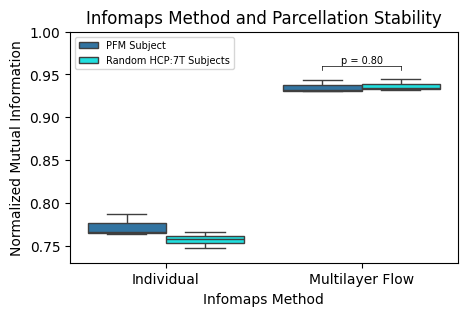

In [193]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.boxplot(data=sd, x="method", y="value", hue="samples", ax=ax, palette=["C0", "cyan"])
# sns.swarmplot(data=sd, x="method", y="value", hue="samples", ax=ax, palette=["C0", "cyan"])
ax.set(ylabel="Normalized Mutual Information", xlabel="Infomaps Method")
ax.set_title("Infomaps Method and Parcellation Stability")
# ax.tick_params(axis='x', labelrotation=45)
# ax.set_ylim(0, 1.05)

t, p = scipy.stats.ttest_ind(sd.query("variable == 'Multilayer Flow - Random HCP:7T Subjects'")["value"],
                      sd.query("variable == 'Multilayer Flow - PFM Subject'")["value"])

ax.plot([0.8, 1.2], [0.96, 0.96], color="k", linewidth=0.5)
ax.plot([0.8, 0.8], [0.955, 0.96], color="k", linewidth=0.5)
ax.plot([1.2, 1.2], [0.955, 0.96], color="k", linewidth=0.5)
ax.text(1, 0.961, f"p = {p:.2f}", va="bottom", ha="center", fontsize=7)
ax.set_ylim(0.73, 1.0)
ax.legend(fontsize=7)


In [38]:
t, p = scipy.stats.ttest_ind(sd.query("variable == 'Singlelayer - Random HCP:7T Subjects'")["value"],
                      sd.query("variable == 'Singlelayer - PFM Subject'")["value"])
t,p

(np.float64(-1.613352227862102), np.float64(0.18196529839433068))

In [195]:
network_partitions = [np.load(p) for p in network_partition_paths]
parcel_partitions = [np.load(p) for p in parcel_partition_paths]
parcel_partitions = np.array([p[1] for p in parcel_partitions])
parcel_partitions = parcel_partitions[:, ~np.isnan(parcel_partitions).any(axis=0)].astype(int)

hcp_parcel_partitions = [np.load(p) for p in hcp_parcel_partition_paths]
hcp_parcel_partitions = np.array([p[1] for p in hcp_parcel_partitions])
hcp_parcel_partitions = hcp_parcel_partitions[:, ~np.isnan(hcp_parcel_partitions).any(axis=0)].astype(int)
sparse_vFC_s = [scipy.sparse.load_npz(p) for p in vfc_paths]

NameError: name 'parcel_partition_paths' is not defined

In [329]:
z = network_partitions[0][0].astype(int)
h = network_partitions[1][0].astype(int)
g = network_partitions[2][0].astype(int)

In [331]:
imi_d_s = [nmis(parcel_partitions[0], np) for np in parcel_partitions]
imi_combos_d_s = [nmis(p1, p2) for p1, p2 in list(itertools.combinations(parcel_partitions, 2))]

imi_hcp_combos_d_s = [nmis(p1, p2) for p1, p2 in list(itertools.combinations(hcp_parcel_partitions, 2))]

In [332]:
from infomap import Infomap

In [274]:
matrices = sparse_vFC_s

im = Infomap(multilayer_relax_limit=1)
n = np.sum([vfc.nnz for vfc in matrices])

for layer, matrix in enumerate(matrices):
    # matrix = matrix[:5000, :5000]
    # nodes = tuple((layer * matrix.shape[0] + i, f"l{layer}_{i}") for i in range(matrix.shape[0]))
    # im.add_nodes(nodes)
    pbar = tqdm(desc="Adding links", total=matrix.nnz, leave=False)
    # for r_i, c_i in zip(*matrix.nonzero()):
    print(len(matrix.data))
    for r_i, c_i, fc_i in zip(*matrix.nonzero(), matrix.data):
        # matrix[r_i, c_i]
        im.add_multilayer_intra_link(layer, r_i, c_i, weight=fc_i)
        pbar.update(1)
    pbar.close()

Adding links:   0%|          | 0/8397944 [00:00<?, ?it/s]

8397944


Adding links:   0%|          | 0/8397944 [00:00<?, ?it/s]

8397944


Adding links:   0%|          | 0/8397944 [00:00<?, ?it/s]

8397944


In [276]:
im.run(num_trials=1)

. Found 6 levels with codelength 8.810062358

=> Trial 1/1 finished in 357.881514s with codelength 8.81006236


Summary after 1 trial
Best end modular solution in 6 levels:
Per level number of modules:         [          6,         240,        2773,        1760,         141,           0] (sum: 4920)
Per level number of leaf nodes:      [          0,           0,       10579,      176954,       82601,        3712] (sum: 273846)
Per level average child degree:      [          6,          40,     55.6333,     64.4479,     47.0125,     26.3262] (average: 58.3207)
Per level codelength for modules:    [0.025894546, 0.518942739, 1.612139210, 0.587119799, 0.023156288, 0.000000000] (sum: 2.767252582)
Per level codelength for leaf nodes: [0.000000000, 0.000000000, 0.262255605, 4.066631136, 1.651026150, 0.062896886] (sum: 6.042809777)
Per level codelength total:          [0.025894546, 0.518942739, 1.874394815, 4.653750935, 1.674182438, 0.062896886] (sum: 8.810062358)

  Infomap ends at 2026-01-15

In [372]:
r = []
for node in im.nodes:
    r.append([node.module_id, node.layer_id, node.node_id])
r = pd.DataFrame(r, columns=["mod", "layer", "node"])
# r.to_csv("imf_hcp_save.csv")
r = pd.read_csv("imf_save.csv")
# r = pd.read_csv("imf_hcp_save.csv")

In [373]:
v = np.full((len(matrices), matrix.shape[0]), fill_value=np.nan)

for layer, df in r.groupby("layer"):
    v[layer][df["node"]] = df["mod"]
v = v[:, ~np.isnan(v).any(axis=0)]

In [374]:
imf_combos_d_s = [calc_mean_dice(p1, p2) for p1, p2 in list(itertools.combinations(v, 2))]
imf_combos_d_s

[np.float64(0.980599076643026),
 np.float64(0.9755289300158059),
 np.float64(0.9752026984638159)]

In [301]:
imf_d_s = [nmis(v[0], v_i) for v_i in v]
imf_combos_d_s = [nmis(p1, p2) for p1, p2 in list(itertools.combinations(v, 2))]

In [302]:
imf_combos_d_s

[np.float64(0.8598098538759791),
 np.float64(0.8597494616565093),
 np.float64(0.8923214435226252)]

In [305]:
# np.save("imf_hcp_combos_d_s.npy", imf_combos_d_s)
# np.save("imf_combos_d_s.npy", imf_combos_d_s)
imf_combos_d_s = np.load("imf_combos_d_s.npy")
imf_hcp_combos_d_s = np.load("imf_hcp_combos_d_s.npy")

In [307]:
imf_combos_d_s, imf_hcp_combos_d_s

(array([0.94347052, 0.93161125, 0.93062284]),
 array([0.85980985, 0.85974946, 0.89232144]))

In [308]:
import itertools

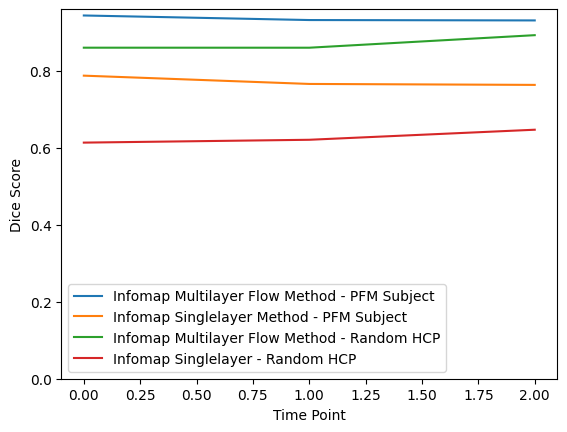

In [333]:
fig, ax = plt.subplots()
ax.plot(imf_combos_d_s, label="Infomap Multilayer Flow Method - PFM Subject")
ax.plot(imi_combos_d_s, label="Infomap Singlelayer Method - PFM Subject")
ax.plot(imf_hcp_combos_d_s, label="Infomap Multilayer Flow Method - Random HCP")
ax.plot(imi_hcp_combos_d_s, label="Infomap Singlelayer - Random HCP")
ax.legend()
ax.set_ylim(0, None)
ax.set(xlabel="Time Point", ylabel="Dice Score")
fig.savefig("infomap_flow_comparisons.png")

In [381]:
sd = pd.DataFrame({
                   "Singlelayer - PFM Subject": imi_combos_d_s,
                   "Multilayer Flow - PFM Subject":imf_combos_d_s,
                   "Singlelayer - Random HCP Subjects": imi_hcp_combos_d_s,
                   "Multilayer Flow - Random HCP Subjects":imf_hcp_combos_d_s,
                   "x": np.arange(3)})
sd = sd.melt(id_vars=["x"])
sd

sd["method"] = sd["variable"].str.split("-").str[0].str.strip()
sd["samples"] = sd["variable"].str.split("-").str[1].str.strip()
sd

,x,variable,value,method,samples
0,0,Singlelayer - PFM Subject,0.787181,Singlelayer,PFM Subject
1,1,Singlelayer - PFM Subject,0.765647,Singlelayer,PFM Subject
2,2,Singlelayer - PFM Subject,0.763175,Singlelayer,PFM Subject
3,0,Multilayer Flow - PFM Subject,0.980599,Multilayer Flow,PFM Subject
4,1,Multilayer Flow - PFM Subject,0.975529,Multilayer Flow,PFM Subject
5,2,Multilayer Flow - PFM Subject,0.975203,Multilayer Flow,PFM Subject
6,0,Singlelayer - Random HCP Subjects,0.613253,Singlelayer,Random HCP Subjects
7,1,Singlelayer - Random HCP Subjects,0.620627,Singlelayer,Random HCP Subjects
8,2,Singlelayer - Random HCP Subjects,0.646748,Singlelayer,Random HCP Subjects
9,0,Multilayer Flow - Random HCP Subjects,0.859810,Multilayer Flow,Random HCP Subjects


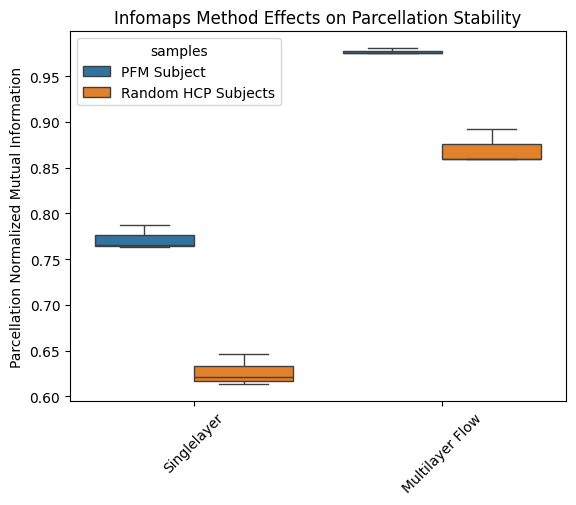

In [382]:
fig, ax = plt.subplots()
# sns.boxplot(data=sd, x="samples", y="value", hue="method", ax=ax)
# ax.set(xlabel="Parcellation Normalized Mutual Information", ylabel="")

sns.boxplot(data=sd, x="method", y="value", hue="samples", ax=ax)
ax.set(ylabel="Parcellation Normalized Mutual Information", xlabel="")
ax.set_title("Infomaps Method Effects on Parcellation Stability")
ax.tick_params(axis='x', labelrotation=45)
# ax.set_ylim(0, 1.05)

<Axes: xlabel='x', ylabel='value'>

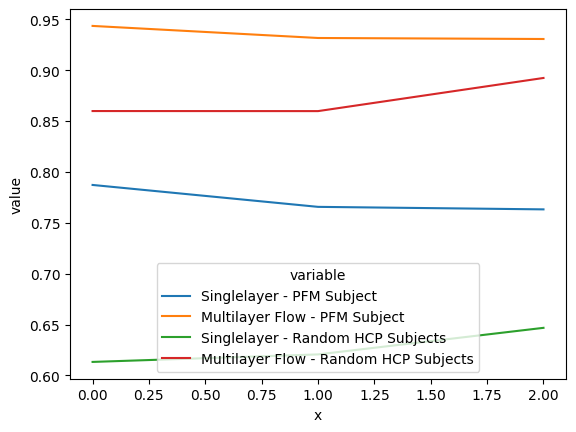

In [352]:
fig, ax = plt.subplots()
sns.lineplot(data=sd, x="x", y="value", hue="variable", ax=ax)

# Network Size Stability

In [42]:
csv_paths = glob.glob(test_dir + "*duration-25m*kms*.csv")

<Axes: xlabel='layer', ylabel='vp'>

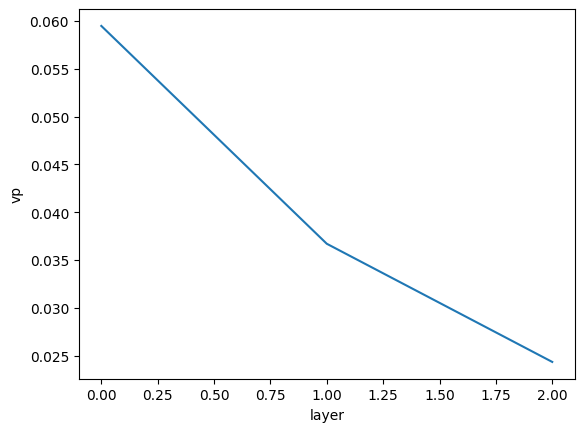

In [84]:
sns.lineplot(data=df_s.query("network == 'Salience'"), x="layer", y="vp")

<Axes: xlabel='p_area', ylabel='network'>

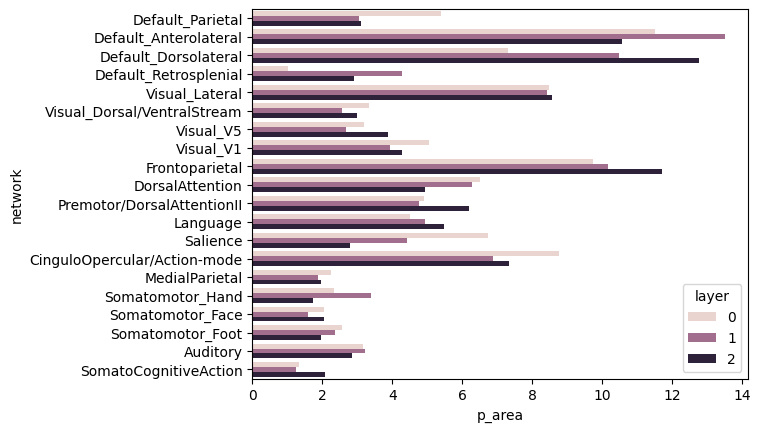

In [85]:
df_s = [pd.read_csv(p).assign(layer=i) for i, p in enumerate(csv_paths)]
df_s = pd.concat([df.assign(p_area=df["area"] / df["area"].sum() * 100).assign(vp=df["vertex_count"]/59_412) for df in df_s])

sns.barplot(data=df_s, x="p_area", y="network", hue="layer")